In [1]:
import pysmile
import pysmile_license
from pathlib import Path
from pysmile.learning import DataSet, EM
import itertools
from expdef import Experiment, Analytic, Result
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fileName = "DBNfromAG_learned.xdsl"
dataFileName = "dbnLogs100.csv"
targetNodes = ["tomcatWebServer_bruteForce", "DMZ_scanIP", "historian_scanVuln", "IED1_DERfailure"]
fixedNodes = ["historianServer_remoteShellAND", "MMSclient1_AND52", "MMSserver1_NodeAND23", "historianServer_NodeOR1"]
numSlices = 100

algoTypeExact = False

In [3]:
net = pysmile.Network()
net.read_file(fileName)
net.set_slice_count(numSlices)
if not algoTypeExact:
    # Set default inference algorithm and parameters
    net.set_bayesian_algorithm(pysmile.BayesianAlgorithmType.EPIS_SAMPLING)
    #pysmile.EPISParams.num_state_big
    # Print default EPIS algorithm parameters
    episParams = net.get_epis_params()
    episParams.propagation_length = 20  # Example modification
    net.set_epis_params(episParams)
    print("Propagation length: ", episParams.propagation_length)
    print("Num state small:", episParams.num_state_small)
    print("Num state medium:", episParams.num_state_medium)
    print("Num state big:", episParams.num_state_big)
else:
    net.set_bayesian_algorithm(pysmile.BayesianAlgorithmType.LAURITZEN)

Propagation length:  20
Num state small: 5
Num state medium: 8
Num state big: 20


In [4]:
def plotDefinitions(net: pysmile.Network):
    nodeHandles = net.get_all_nodes()
    nodeIds = net.get_all_node_ids()
    for nodeHandle, nodeId in zip(nodeHandles, nodeIds):
        nodeDef = net.get_node_definition(nodeHandle)
        nodeOutcomes = net.get_outcome_ids(nodeHandle)
        print(f"Node ID: {nodeId}, Definition: {nodeDef}, Outcomes: {nodeOutcomes}")

In [ ]:
from validator import Validator

ext_ev_every_n_slices = [1,2,5]
numFolds = 5

validator: Validator = Validator(net, dataFileName, fixedNodes)
for targetNode in targetNodes:
    validator.addClassNode(targetNode)

full_results_df = pd.DataFrame()
for ev_every_n_slices in ext_ev_every_n_slices:
    print(f"Evaluating with evEveryNSlices = {ev_every_n_slices}")
    validator.set_ev_every_n_slices(ev_every_n_slices)
    results_df = validator.kFold(nFolds=numFolds)
    results_df.to_csv(f"results/{numFolds}_folds-evEveryNSlices_{ev_every_n_slices}.csv", index=False)
    full_results_df = pd.concat([full_results_df, results_df], ignore_index=True)

Evaluating with evEveryNSlices = 1
Fold 1/5 -- Accuracy: 0.9818, Precision: 0.9913, Recall: 0.9833, F1-score: 0.9873, MCC: 0.9551
Fold 2/5 -- Accuracy: 0.9835, Precision: 0.9899, Recall: 0.9868, F1-score: 0.9884, MCC: 0.9600
Fold 3/5 -- Accuracy: 0.9805, Precision: 0.9870, Recall: 0.9853, F1-score: 0.9862, MCC: 0.9532
Fold 4/5 -- Accuracy: 0.9822, Precision: 0.9906, Recall: 0.9839, F1-score: 0.9873, MCC: 0.9580
Fold 5/5 -- Accuracy: 0.9825, Precision: 0.9865, Recall: 0.9883, F1-score: 0.9874, MCC: 0.9588
Average Accuracy: 0.9821 ± 0.0010
Average Precision: 0.9891 ± 0.0019
Average Recall: 0.9855 ± 0.0018
Average F1-score: 0.9873 ± 0.0007
Average MCC: 0.9570 ± 0.0025
Evaluating with evEveryNSlices = 2
Fold 1/5 -- Accuracy: 0.9802, Precision: 0.9916, Recall: 0.9809, F1-score: 0.9862, MCC: 0.9516
Fold 2/5 -- Accuracy: 0.9811, Precision: 0.9866, Recall: 0.9868, F1-score: 0.9867, MCC: 0.9541
Fold 3/5 -- Accuracy: 0.9792, Precision: 0.9872, Recall: 0.9833, F1-score: 0.9853, MCC: 0.9503
Fold 4

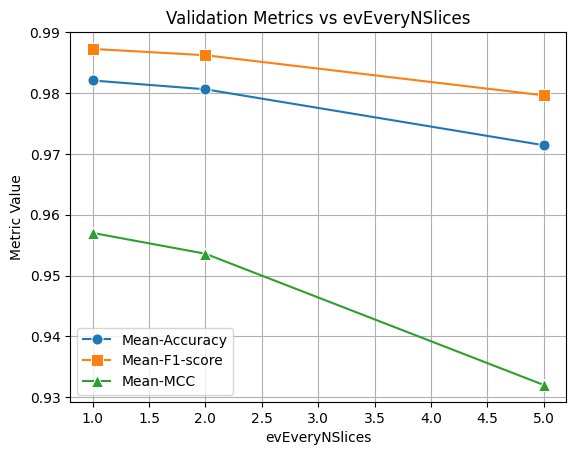

In [37]:
# Plot the full results using a line plot (one line per metric with error bars)
metrics = ['Mean-Accuracy', 'Mean-F1-score', 'Mean-MCC']
metricsStd = [f'Std-{metric.split("-")[1]}' for metric in metrics]
markers = ['o', 's', '^']  # circle, square, triangle
for metric, metricStd, marker in zip(metrics, metricsStd, markers):
    # Set a different marker for each metric
    sns.lineplot(data=full_results_df, x='evEveryN', y=metric, marker=marker, label=metric, markersize=8)
plt.title('Validation Metrics vs evEveryNSlices')
plt.xlabel('evEveryNSlices')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.savefig('plots/validation_metrics_vs_evEveryNSlices.png')